In [32]:
import scipy.io
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
import pandas as pd
from scipy.fft import fft,fftfreq,ifft
from scipy.signal import hilbert
from scipy.stats import kurtosis
from scipy.signal import butter, filtfilt


In [33]:
data = scipy.io.loadmat('archive/cwru/IR007_0.mat')
# Finding the key (usually starts with X)
vibration = data['X105_DE_time'].flatten() 
fs = 12000

# Create time axis
time = np.arange(len(vibration)) / fs

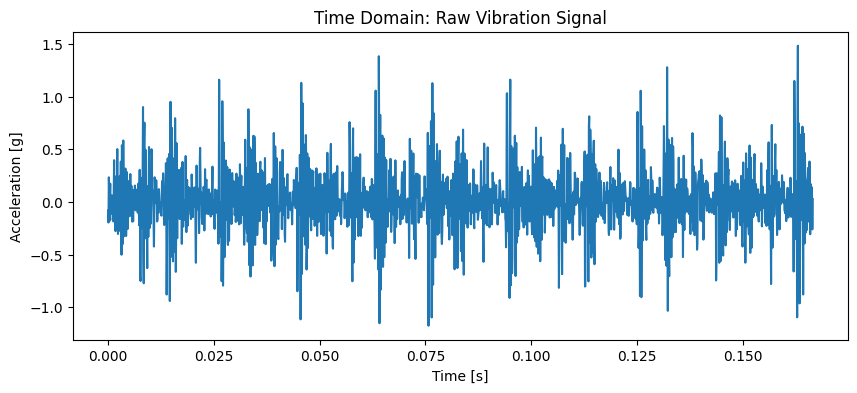

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(time[:2000], vibration[:2000]) # Plot first 2000 points
plt.title("Time Domain: Raw Vibration Signal")
plt.xlabel("Time [s]")
plt.ylabel("Acceleration [g]")
plt.show()

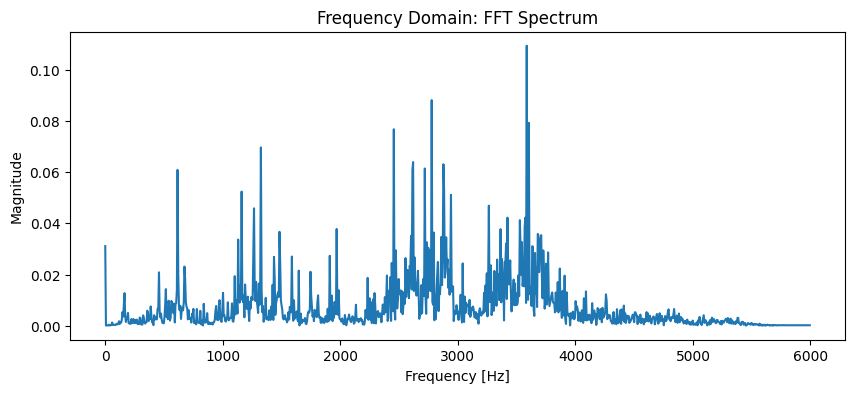

In [31]:

N = 2048 # Window size
v_window = vibration[:N]
yf = fft(v_window)
xf = fftfreq(N, 1/fs)[:N//2]
magnitude = np.abs(yf)

plt.figure(figsize=(10, 4))
plt.plot(xf, 2.0/N * np.abs(yf[:N//2]))
plt.title("Frequency Domain: FFT Spectrum")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.show()

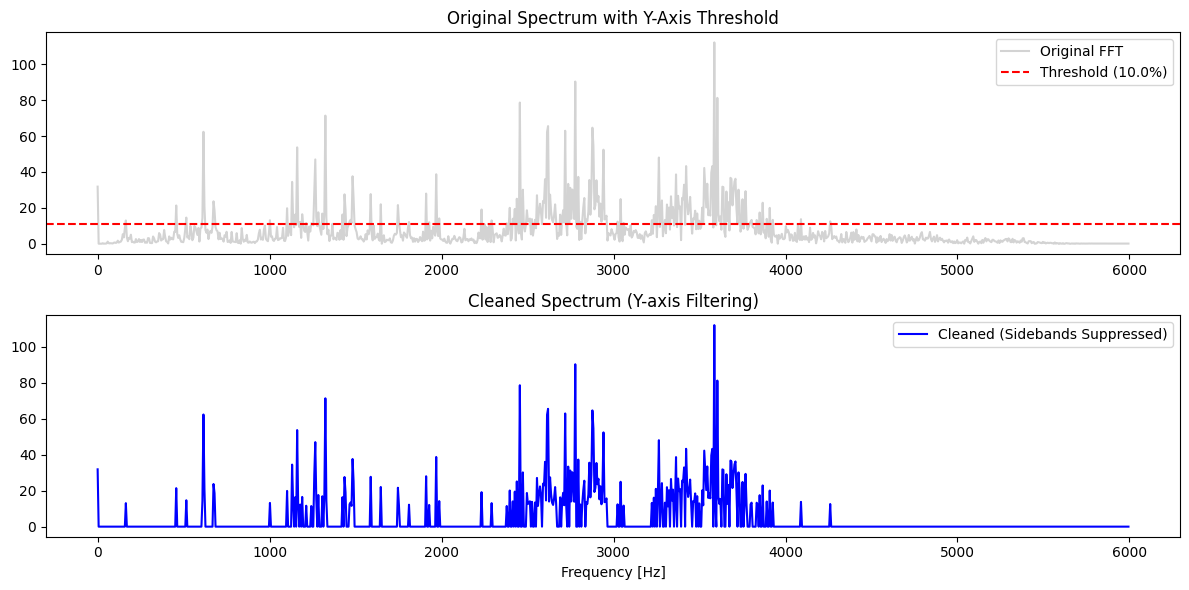

In [35]:
threshold_ratio = 0.10 
gamma = threshold_ratio * np.max(magnitude)


yf_cleaned = yf.copy()
yf_cleaned[magnitude < gamma] = 0


filtered_signal = ifft(yf_cleaned).real


plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(xf[:N//2], magnitude[:N//2], color='lightgray', label='Original FFT')
plt.axhline(y=gamma, color='r', linestyle='--', label=f'Threshold ({threshold_ratio*100}%)')
plt.title("Original Spectrum with Y-Axis Threshold")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(xf[:N//2], np.abs(yf_cleaned[:N//2]), color='blue', label='Cleaned (Sidebands Suppressed)')
plt.title("Cleaned Spectrum (Y-axis Filtering)")
plt.xlabel("Frequency [Hz]")
plt.legend()

plt.tight_layout()
plt.show()

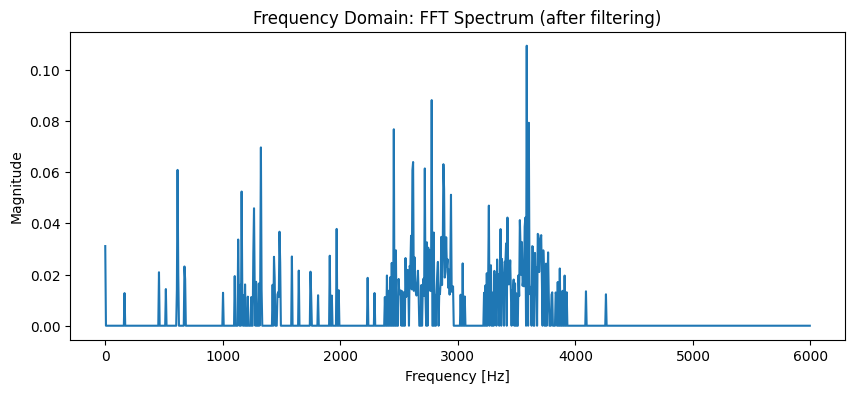

In [36]:
N = 2048 # Window size
v_window = filtered_signal[:N]
yf = fft(v_window)
xf = fftfreq(N, 1/fs)[:N//2]

plt.figure(figsize=(10, 4))
plt.plot(xf, 2.0/N * np.abs(yf[:N//2]))
plt.title("Frequency Domain: FFT Spectrum (after filtering)")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.show()

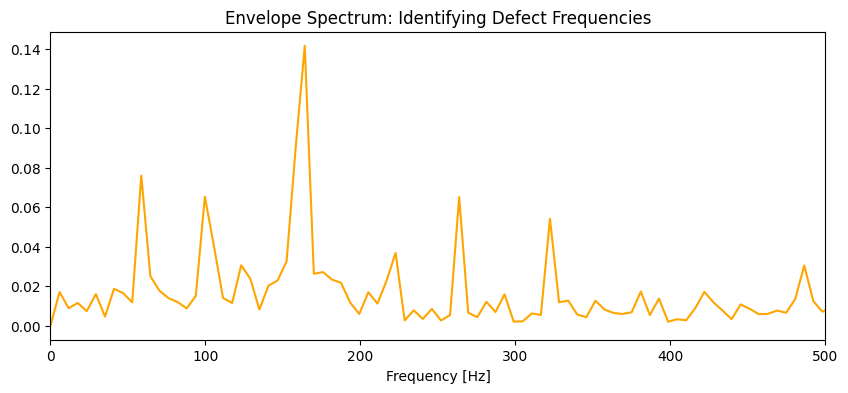

In [38]:
envelope = np.abs(hilbert(filtered_signal[:N]))

env_spec = fft(envelope - np.mean(envelope))

plt.figure(figsize=(10, 4))
plt.plot(xf, 2.0/N * np.abs(env_spec[:N//2]), color='orange')
plt.title("Envelope Spectrum: Identifying Defect Frequencies")
plt.xlabel("Frequency [Hz]")
plt.xlim(0, 500) 
plt.show()

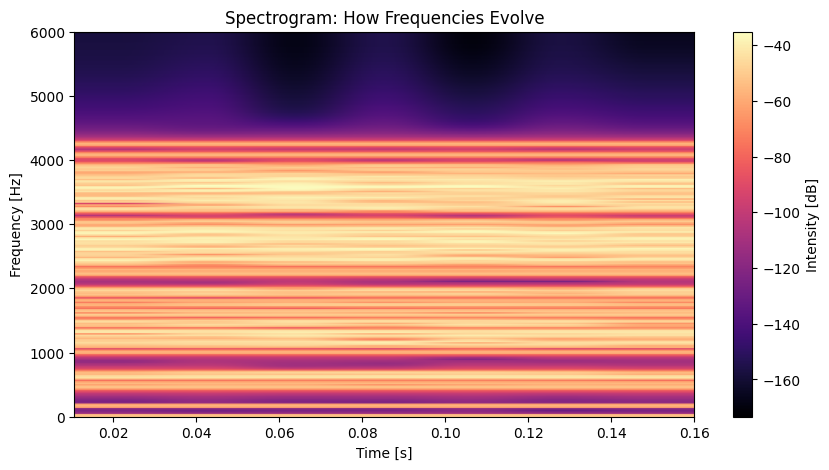

In [39]:
plt.figure(figsize=(10, 5))
plt.specgram(filtered_signal[:12000], Fs=fs, NFFT=512, noverlap=256, cmap='magma')
plt.title("Spectrogram: How Frequencies Evolve")
plt.ylabel("Frequency [Hz]")
plt.xlabel("Time [s]")
plt.colorbar(label='Intensity [dB]')
plt.show()

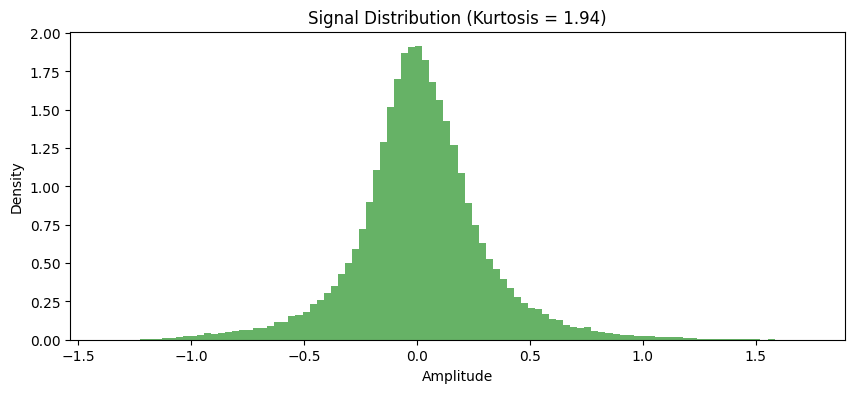

In [40]:
plt.figure(figsize=(10, 4))
plt.hist(vibration, bins=100, color='green', alpha=0.6, density=True)
plt.title(f"Signal Distribution (Kurtosis = {kurtosis(filtered_signal):.2f})")
plt.xlabel("Amplitude")
plt.ylabel("Density")
plt.show()

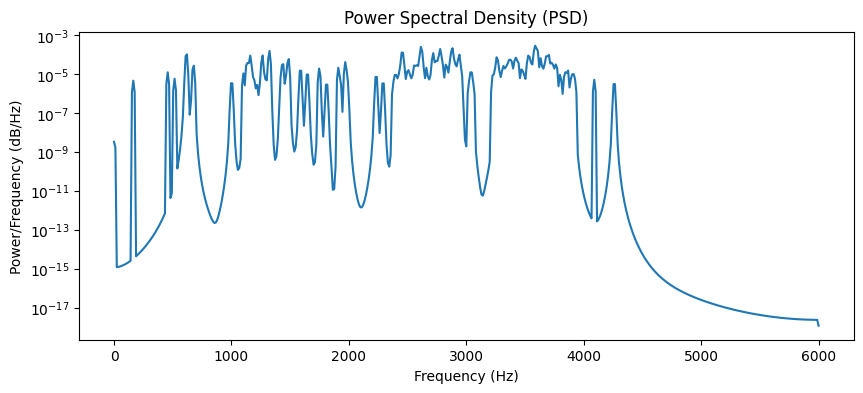

In [41]:
from scipy.signal import welch

frequencies, psd = welch(filtered_signal, fs, nperseg=1024)

plt.figure(figsize=(10, 4))
plt.semilogy(frequencies, psd)
plt.title("Power Spectral Density (PSD)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power/Frequency (dB/Hz)")
plt.show()